In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


model_id='meta-llama/Llama-3.1-8B-Instruct' #"meta-llama/Llama-2-7b-chat-hf" #'meta-llama/Llama-3.1-8B-Instruct' #
dataset ='known_1000' # "squad_v2.0_clean" # 'known_1000' # 
attributon_type = 'input'

In [2]:
def split_key_value(key):
    parts = key.split('_noise_')
    if len(parts) != 2:
        return None, None
    method = parts[0]  # Get first part (e.g., 'all' from 'all_noise')
    noise_level = round(float(parts[1]), 10)  # Convert noise level to float and round
    return method, noise_level

In [3]:
def split_meta_key_value(key):
    parts = key.split('__')
    if len(parts) != 2:
        return None, None
    method = parts[0]  # Get first part (e.g., 'all' from 'all_noise')
    noise_level = round(float(parts[1]), 10)  # Convert noise level to float and round
    return method, noise_level

/tmp/ipykernel_217777/2542597226.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  recover_auc = float(np.trapz(rec_y, rec_x))
/tmp/ipykernel_217777/2542597226.py:107: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  disrupt_auc = float(np.trapz(dis_y, dis_x))


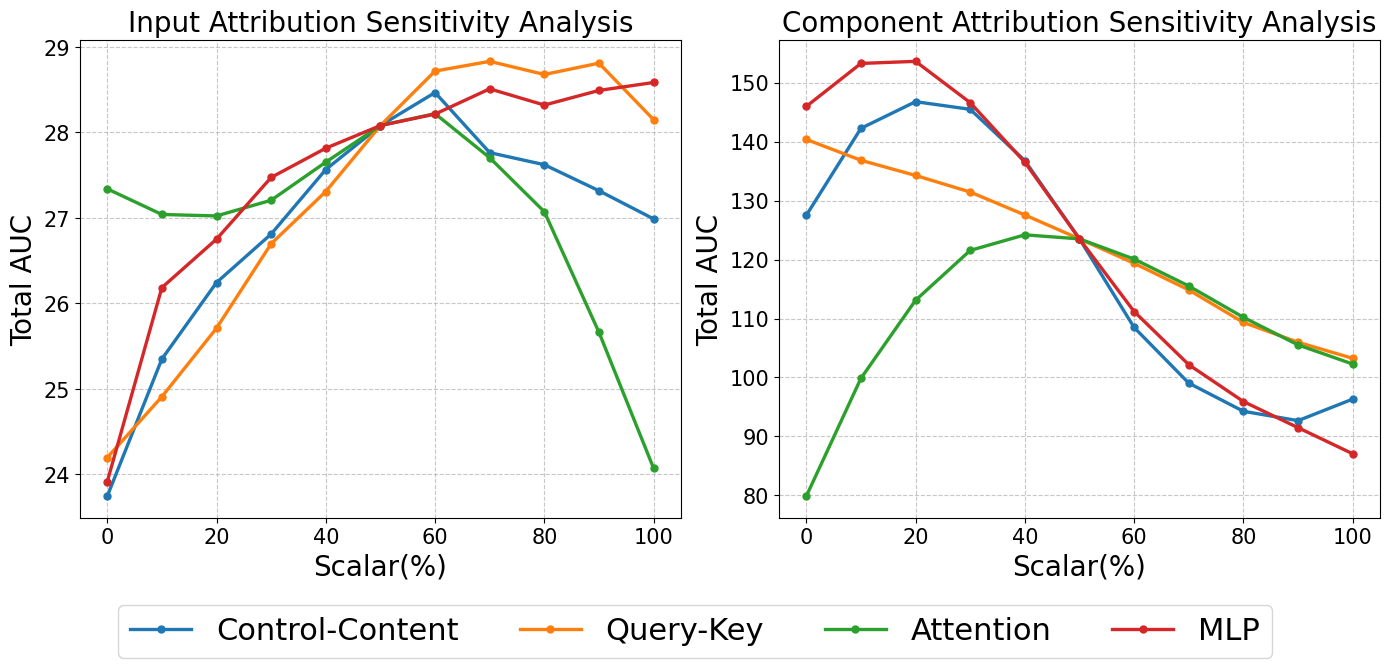

In [9]:
# known_1000: Total AUC by 4 DPA sensitivity settings
from glob import glob
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal, ROUND_DOWN

ablation_dir = "/mnt/dacslab/dpa/results/ablation__meta_llama_llama_3.1_8b_instruct__known_1000"
dataset = "known_1000"
setting_order = ["Control-Content", "Query-Key", "Attention", "MLP"]
setting_colors = {
    "Control-Content": "tab:blue",
    "Query-Key": "tab:orange",
    "Attention": "tab:green",
    "MLP": "tab:red",
}


def _format_token(value, decimals):
    text = f"{value:.{decimals}f}"
    if re.fullmatch(r"[0-9]+\.[0-9]0", text):
        text = text[:-1]
    return text.replace(".", "")


def _generate_setting_label_map():
    label_map = {}

    for i in range(11):
        p = Decimal(i) / Decimal(10)
        res = Decimal("1.0") - p

        res_half = (res / Decimal(2)).quantize(Decimal("0.00"), rounding=ROUND_DOWN)
        p_half = (p / Decimal(2)).quantize(Decimal("0.00"), rounding=ROUND_DOWN)
        res_quarter = (res / Decimal(4)).quantize(Decimal("0.00"), rounding=ROUND_DOWN)
        p_quarter = (p / Decimal(4)).quantize(Decimal("0.00"), rounding=ROUND_DOWN)

        c_p = _format_token(p, 1)
        c_res = _format_token(res, 1)
        c_res_half = _format_token(res_half, 2)
        c_p_half = _format_token(p_half , 2)
        c_res_quarter = _format_token(res_quarter, 2)
        c_p_quarter = _format_token(p_quarter, 2)

        # Exactly mirrors experiments/sh/run_sensitivity_anaysis.sh naming logic.
        label_specs = [
            ("Control-Content", float(p), f"{c_res_half}_{c_res_half}_{c_p}_{c_res}_{c_p}"),
            ("Query-Key", float(p), f"{c_res_half}_{c_p_half}_05_05_05"),
            ("Attention", float(p), f"{c_res_half}_{c_res_half}_{c_p}_05_05"),
            ("MLP", float(p), f"025_025_05_{c_res}_{c_p}"),
        ]

        for setting_name, scale_val, label in label_specs:
            label_map.setdefault(label, []).append((setting_name, round(scale_val, 1)))

    return label_map


SETTING_LABEL_MAP = _generate_setting_label_map()


def label_to_setting_scales(label):
    return SETTING_LABEL_MAP.get(label, [])


def get_base_points(attribution, ablation_type):
    if attribution == "component":
        if ablation_type == "recover":
            return {1e-6: 0.0, 1.0: 100.0}
        return {1e-10: 100.0}
    if ablation_type == "recover":
        return {1.0: 100.0}
    return {0.0: 100.0}


def load_avg_scores(file_path, attribution, ablation_type):
    with open(file_path, "r") as file:
        data_all = json.load(file)

    grouped = {}
    for row in data_all:
        scores = row.get("scores", {})
        for key, value in scores.items():
            if not key.startswith("noise_"):
                continue
            noise_level = float(key.replace("noise_", ""))
            grouped.setdefault(noise_level, []).append(float(value))

    avg_scores = dict(get_base_points(attribution, ablation_type))
    for noise_level, vals in grouped.items():
        avg_scores[noise_level] = 100.0 - float(np.mean(vals))
    return avg_scores


def compute_total_auc(recover_path, disrupt_path, attribution):
    recover_scores = load_avg_scores(recover_path, attribution, "recover")
    disrupt_scores = load_avg_scores(disrupt_path, attribution, "disrupt")

    rec_x = np.array(sorted(recover_scores.keys()))
    rec_y = np.array([recover_scores[x] for x in rec_x])
    dis_x = np.array(sorted(disrupt_scores.keys()))
    dis_y = np.array([disrupt_scores[x] for x in dis_x])

    recover_auc = float(np.trapz(rec_y, rec_x))
    disrupt_auc = float(np.trapz(dis_y, dis_x))
    return recover_auc - disrupt_auc


def dpa_label_from_path(file_path, prefix):
    base_name = os.path.basename(file_path)
    return base_name.replace(prefix, "").replace(".json", "").replace("dpa_", "")


input_recover_map = {
    dpa_label_from_path(p, "input_recover_"): p
    for p in glob(os.path.join(ablation_dir, "input_recover_dpa_*.json"))
}
input_disrupt_map = {
    dpa_label_from_path(p, "input_disrupt_"): p
    for p in glob(os.path.join(ablation_dir, "input_disrupt_dpa_*.json"))
}
component_recover_map = {
    dpa_label_from_path(p, "component_recover_"): p
    for p in glob(os.path.join(ablation_dir, "component_recover_dpa_*.json"))
}
component_disrupt_map = {
    dpa_label_from_path(p, "component_disrupt_"): p
    for p in glob(os.path.join(ablation_dir, "component_disrupt_dpa_*.json"))
}

input_common_labels = sorted(
    set(input_recover_map.keys())
    & set(input_disrupt_map.keys())
)
component_common_labels = sorted(
    set(component_recover_map.keys())
    & set(component_disrupt_map.keys())
)

if not input_common_labels and not component_common_labels:
    raise FileNotFoundError("No common DPA parameter labels were found for recover/disrupt files")

if not input_common_labels:
    print("Warning: no common input recover/disrupt labels were found.")
if not component_common_labels:
    print("Warning: no common component recover/disrupt labels were found.")

input_series = {k: {} for k in setting_order}
component_series = {k: {} for k in setting_order}

for label in input_common_labels:
    matches = label_to_setting_scales(label)
    if not matches:
        continue

    input_auc = compute_total_auc(input_recover_map[label], input_disrupt_map[label], attribution="input")
    for setting_name, scale_val in matches:
        input_series[setting_name].setdefault(scale_val, []).append(input_auc)

for label in component_common_labels:
    matches = label_to_setting_scales(label)
    if not matches:
        continue

    component_auc = compute_total_auc(component_recover_map[label], component_disrupt_map[label], attribution="component")
    for setting_name, scale_val in matches:
        component_series[setting_name].setdefault(scale_val, []).append(component_auc)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
legend_handles = []
legend_labels = []

for setting_name in setting_order:
    if input_series[setting_name]:
        x_vals = sorted(input_series[setting_name].keys())
        x_plot = [x * 100.0 for x in x_vals]
        y_input = [float(np.mean(input_series[setting_name][x])) for x in x_vals]

        line, = axes[0].plot(
            x_plot,
            y_input,
            marker="o",
            linewidth=2.4,
            markersize=5,
            color=setting_colors[setting_name],
            label=setting_name,
        )
        if setting_name not in legend_labels:
            legend_handles.append(line)
            legend_labels.append(setting_name)

    if component_series[setting_name]:
        x_vals = sorted(component_series[setting_name].keys())
        x_plot = [x * 100.0 for x in x_vals]
        y_component = [float(np.mean(component_series[setting_name][x])) for x in x_vals]

        line_component, = axes[1].plot(
            x_plot,
            y_component,
            marker="o",
            linewidth=2.4,
            markersize=5,
            color=setting_colors[setting_name],
            label=setting_name,
        )
        if setting_name not in legend_labels:
            legend_handles.append(line_component)
            legend_labels.append(setting_name)

axes[0].set_title("Input Attribution Sensitivity Analysis", fontsize=20)
axes[0].set_xlabel("Scalar(%)", fontsize=20)
axes[0].set_ylabel("Total AUC", fontsize=20)
axes[0].grid(True, linestyle="--", alpha=0.7)
axes[0].tick_params(axis="both", labelsize=15)

axes[1].set_title("Component Attribution Sensitivity Analysis", fontsize=20)
axes[1].set_xlabel("Scalar(%)", fontsize=20)
axes[1].set_ylabel("Total AUC", fontsize=20)
axes[1].grid(True, linestyle="--", alpha=0.7)
axes[1].tick_params(axis="both", labelsize=15)

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    ncol=4,
    fontsize=22,
    bbox_to_anchor=(0.5, 0.03),
)

plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()